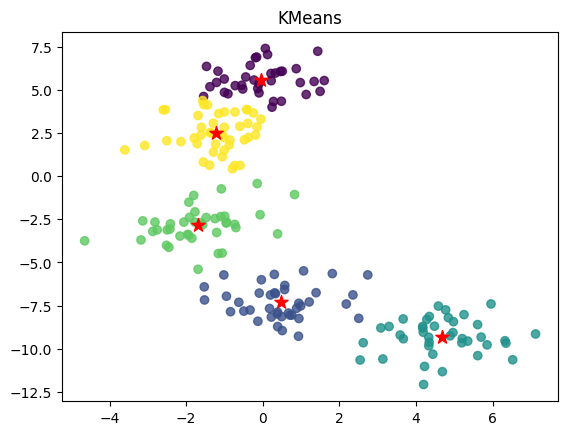

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
 
# create a dataset of 200 samples
# and 5 clusters
features, labels = make_blobs(
    n_samples=200,
    centers=5
)

# Instanciate the model with 5 'K' clusters
# and 10 iterations with different
# centroid seed 
model = KMeans(
    n_clusters=5,
    n_init=10,
    random_state=42
    )
 
# train the model
model.fit(features)
 
# make a prediction on the data
p_labels = model.predict(features)

import matplotlib.pyplot as plt
plt.style.use('default')
 
X = features[:,0]
y = features[:,1]
 
plt.scatter(X, y, c=p_labels, alpha=0.8)
 
cluster_centers = model.cluster_centers_
cs_x = cluster_centers[:,0]
cs_y = cluster_centers[:,1]
 
plt.scatter(cs_x, cs_y, marker='*', s=100, c='r')
plt.title('KMeans')
plt.show()


In [2]:
cluster_centers

array([[-0.03907026,  5.59186097],
       [ 0.48286438, -7.30158853],
       [ 4.67107573, -9.29057192],
       [-1.68565172, -2.84762014],
       [-1.23039068,  2.50152345]])

In [3]:
import numpy as np
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
import json

token_provider = get_bearer_token_provider(
    DefaultAzureCredential(), "https://cognitiveservices.azure.com/.default"
)

client = AzureOpenAI(
  azure_endpoint = "https://aifsweden.openai.azure.com/", 
  azure_ad_token_provider=token_provider,
  api_version="2025-03-01-preview"
)

response = client.responses.create(
    model="gpt-5-mini",
    #temperature=0.7,
    reasoning={"effort": "medium"},
    input="""Take this data and split into 5 clusters same way as k means clustering might do. I just want the location of the 5 clusters not the code:""" + json.dumps(features.tolist()) + "  labels are : " + json.dumps(labels.tolist()),
)

print(response.output_text)

print(response.usage)


Using the labels you provided (0–4) and the 200 2D points, the k-means cluster centers (centroids) are:

- Cluster 0 (41 points): (≈ 0.6948, −4.7812)
- Cluster 1 (50 points): (≈ 0.5570, −1.0403)
- Cluster 2 (41 points): (≈ −0.5908, −0.6749)
- Cluster 3 (25 points): (≈ −0.2554, −0.6627)
- Cluster 4 (43 points): (≈ 1.1919, −4.0450)

If you want more precision (more decimal places) or the centroid coordinates in a different order (e.g., sorted by x or y), tell me and I’ll provide them.
ResponseUsage(input_tokens=4428, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=22775, output_tokens_details=OutputTokensDetails(reasoning_tokens=22592), total_tokens=27203)


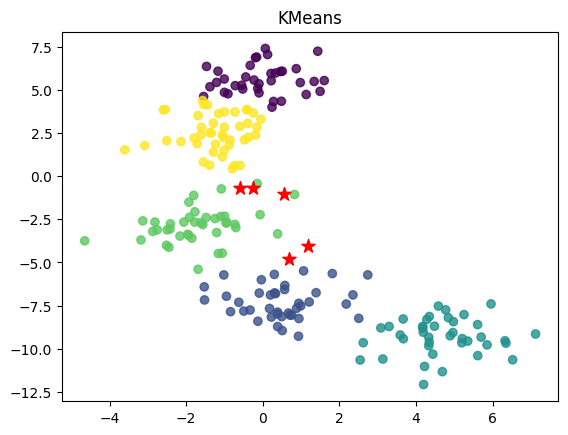

In [ ]:
plt.scatter(X, y, c=p_labels, alpha=0.8)

cluster_centers = model.cluster_centers_
cs_x = [0.6948,0.5570,-0.5908,-0.2554,1.1919]
cs_y = [-4.7812,-1.0403,-0.6749,-0.6627,-4.0450]
 
plt.scatter(cs_x, cs_y, marker='*', s=100, c='r')
plt.title('KMeans')
plt.show()


In [ ]:
# Using the labels you provided (0–4) and the 200 2D points, the k-means cluster centers (centroids) are:

# - Cluster 0 (41 points): (≈ 0.6948, −4.7812)
# - Cluster 1 (50 points): (≈ 0.5570, −1.0403)
# - Cluster 2 (41 points): (≈ −0.5908, −0.6749)
# - Cluster 3 (25 points): (≈ −0.2554, −0.6627)
# - Cluster 4 (43 points): (≈ 1.1919, −4.0450)

# If you want more precision (more decimal places) or the centroid coordinates in a different order (e.g., sorted by x or y), tell me and I’ll provide them.
# ResponseUsage(input_tokens=4428, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=22775, output_tokens_details=OutputTokensDetails(reasoning_tokens=22592), total_tokens=27203)

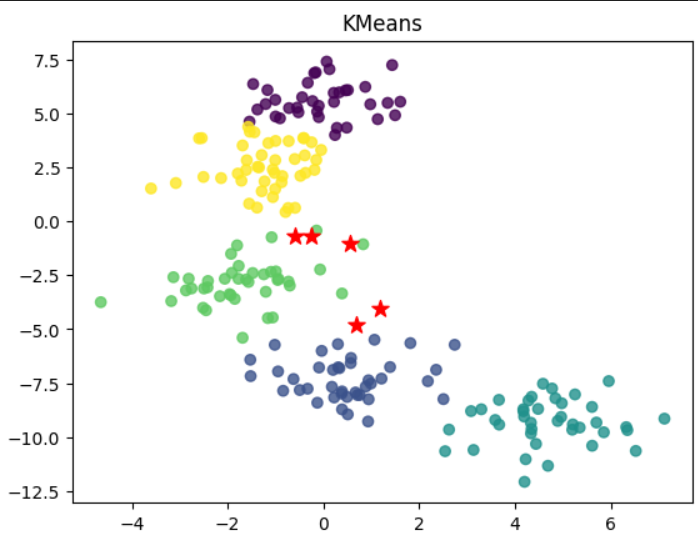